In [143]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

# Для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [144]:
IMAGE_DIR = "dataset/images"          # папка с исходными фото
MASK_DIR = "dataset/masks"            # папка с масками (одноканальные, значения 0..3)
MODEL_SAVE_PATH = "best_model.pth"

# Параметры обучения
BATCH_SIZE = 4
NUM_EPOCHS = 70
LEARNING_RATE = 1e-4
NUM_CLASSES = 4               # фон, пол, стена, мусор
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Соотношение train/val
VAL_SPLIT = 0.2

In [145]:
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Читаем изображение (BGR -> RGB)
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Маска – одноканальная, значения 0-3
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        # Важно: маска должна быть целочисленной
        mask = mask.astype(np.int64)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        return image, mask

# Аугментации для тренировки
train_transform = A.Compose([
    A.Resize(512, 512),  # или RandomResizedCrop
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.15, scale_limit=0.25, rotate_limit=20, p=0.6),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
        A.RandomGamma(p=1),
    ], p=0.5),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3,5), p=1),
        A.MotionBlur(blur_limit=5, p=1),
    ], p=0.3),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
    A.Perspective(scale=(0.02, 0.05), p=0.3),   # имитация наклонной съёмки
    A.GridDistortion(p=0.2),                     # небольшие искажения
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Для валидации – только resize и нормализация
val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

C:\Users\DragonSlayer\AppData\Local\Temp\ipykernel_6256\2393919099.py:42: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),


In [146]:
# Получаем список общих файлов
image_filenames = sorted(os.listdir(IMAGE_DIR))
mask_filenames = sorted(os.listdir(MASK_DIR))

# Проверяем соответствие
assert len(image_filenames) == len(mask_filenames), "Количество изображений и масок не совпадает"
for img, msk in zip(image_filenames, mask_filenames):
    assert os.path.splitext(img)[0] == os.path.splitext(msk)[0], f"Имена файлов не совпадают: {img} vs {msk}"

image_paths = [os.path.join(IMAGE_DIR, f) for f in image_filenames]
mask_paths = [os.path.join(MASK_DIR, f) for f in mask_filenames]

# Перемешиваем и делим на train/val
indices = list(range(len(image_paths)))
random.shuffle(indices)
split = int(len(indices) * (1 - VAL_SPLIT))
train_indices = indices[:split]
val_indices = indices[split:]

train_img_paths = [image_paths[i] for i in train_indices]
train_mask_paths = [mask_paths[i] for i in train_indices]
val_img_paths = [image_paths[i] for i in val_indices]
val_mask_paths = [mask_paths[i] for i in val_indices]

# Создаём объекты Dataset
train_dataset = SegmentationDataset(train_img_paths, train_mask_paths, transform=train_transform)
val_dataset = SegmentationDataset(val_img_paths, val_mask_paths, transform=val_transform)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)} изображений, Val: {len(val_dataset)} изображений")


Train: 168 изображений, Val: 42 изображений


In [147]:
# Используем предобученный на ImageNet энкодер (например, resnet34)
model = smp.DeepLabV3Plus(
    encoder_name="se_resnext50_32x4d",        # можно заменить на "efficientnet-b0" и др.
    encoder_weights="imagenet",     # предобученные веса
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None                 # выход – сырые логиты
)
model = model.to(DEVICE)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

c:\Users\DragonSlayer\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DragonSlayer\.cache\huggingface\hub\models--smp-hub--se_resnext50_32x4d.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/111M [00:00<?, ?B/s]

In [148]:
def compute_miou(preds, targets, num_classes=4, ignore_index=None):
    """
    Вычисляет mean IoU (Jaccard index) для батча.
    
    Args:
        preds:  тензор предсказанных классов [B, H, W]
        targets: тензор истинных классов [B, H, W]
        num_classes: количество классов
        ignore_index: класс, который нужно игнорировать (например, 0=фон). 
                      Если None, считаем по всем.
    Returns:
        Средний IoU (float) по всем учитываемым классам.
    """
    iou_per_class = []
    for cls in range(num_classes):
        if ignore_index is not None and cls == ignore_index:
            continue
        # Пиксели, где истина == класс
        target_cls = (targets == cls)
        # Пиксели, где модель предсказала класс
        pred_cls = (preds == cls)
        
        intersection = (target_cls & pred_cls).sum().float()
        union = (target_cls | pred_cls).sum().float()
        
        if union == 0:
            # Класс отсутствует в батче – пропускаем, чтобы не портить среднее
            continue
        
        iou = intersection / union
        iou_per_class.append(iou)
    
    if len(iou_per_class) == 0:
        return torch.tensor(0.0)
    return torch.stack(iou_per_class).mean()

In [149]:
dice_loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
ce_loss_fn = nn.CrossEntropyLoss()

# Коэффициенты для взвешенной суммы (можно настроить)
DICE_WEIGHT = 0.5
CE_WEIGHT = 0.5

# Оптимизатор и планировщик
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [150]:
def visualize_sample(image_tensor, mask_true, mask_pred=None, num_classes=4):
    """Показывает исходное изображение и маски."""
    # Обратная нормализация
    inv_normalize = A.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225],
        max_pixel_value=1.0
    )
    image_np = image_tensor.cpu().permute(1,2,0).numpy()
    image_np = inv_normalize(image=image_np)['image']
    image_np = (image_np * 255).astype(np.uint8)

    mask_true_np = mask_true.cpu().numpy()
    
    fig, axes = plt.subplots(1, 3 if mask_pred is not None else 2, figsize=(12, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Изображение")
    axes[0].axis('off')

    axes[1].imshow(mask_true_np, cmap='jet', vmin=0, vmax=num_classes-1)
    axes[1].set_title("Истинная маска")
    axes[1].axis('off')

    if mask_pred is not None:
        mask_pred_np = mask_pred.cpu().numpy()
        axes[2].imshow(mask_pred_np, cmap='jet', vmin=0, vmax=num_classes-1)
        axes[2].set_title("Предсказанная маска")
        axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [151]:
best_val_loss = float('inf')
early_stopping_patience = 15
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ─── Тренировка ───
    model.train()
    train_loss = 0.0
    train_iou = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]"):
        images = images.to(DEVICE, dtype=torch.float32)
        masks = masks.to(DEVICE, dtype=torch.long)   # для CrossEntropy нужен long
        
        optimizer.zero_grad()
        outputs = model(images)                     # [B, C, H, W]

        # Вычисляем обе потери и комбинируем с заданными весами
        loss_dice = dice_loss_fn(outputs, masks)
        loss_ce = ce_loss_fn(outputs, masks)
        loss = DICE_WEIGHT * loss_dice + CE_WEIGHT * loss_ce

        loss.backward()
        optimizer.step()

        # Подсчёт статистики
        train_loss += loss.item() * images.size(0)
        # IoU для мультикласса (argmax)
        preds = torch.argmax(outputs, dim=1)
        iou = compute_miou(preds, masks, num_classes=NUM_CLASSES, ignore_index=0)
        train_iou += iou.item() * images.size(0)

    train_loss /= len(train_dataset)
    train_iou /= len(train_dataset)

    # ─── Валидация ───
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Val]"):
            images = images.to(DEVICE, dtype=torch.float32)
            masks = masks.to(DEVICE, dtype=torch.long)
            
            outputs = model(images)
            # Комбинированная потеря на валидации
            loss_dice = dice_loss_fn(outputs, masks)
            loss_ce = ce_loss_fn(outputs, masks)
            loss = DICE_WEIGHT * loss_dice + CE_WEIGHT * loss_ce
            
            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            iou = compute_miou(preds, masks, num_classes=NUM_CLASSES, ignore_index=0)
            val_iou += iou.item() * images.size(0)

    val_loss /= len(val_dataset)
    val_iou /= len(val_dataset)

    # Логирование
    print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

    # Планировщик по валидационной ошибке
    scheduler.step(val_loss)

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_iou': val_iou
        }, MODEL_SAVE_PATH)
        print(f"  -> Сохранена лучшая модель (Val Loss = {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Ранняя остановка обучения.")
            break

print("Обучение завершено.")

Epoch 1/70 [Val]: 100%|██████████| 11/11 [00:01<00:00,  8.13it/s]


Epoch  1 | Train Loss: 0.8516 | Train IoU: 0.2576 | Val Loss: 0.6296 | Val IoU: 0.3831
  -> Сохранена лучшая модель (Val Loss = 0.6296)


Epoch 2/70 [Val]: 100%|██████████| 11/11 [00:01<00:00,  8.12it/s]


Epoch  2 | Train Loss: 0.6133 | Train IoU: 0.3962 | Val Loss: 0.4810 | Val IoU: 0.3837
  -> Сохранена лучшая модель (Val Loss = 0.4810)


Epoch 3/70 [Val]: 100%|██████████| 11/11 [00:01<00:00,  8.12it/s]


...

Epoch 61 | Train Loss: 0.1347 | Train IoU: 0.8063 | Val Loss: 0.2602 | Val IoU: 0.6117


Epoch 62/70 [Val]: 100%|██████████| 11/11 [00:01<00:00,  7.58it/s]


Epoch 62 | Train Loss: 0.1381 | Train IoU: 0.7930 | Val Loss: 0.2535 | Val IoU: 0.6189


Epoch 63/70 [Val]: 100%|██████████| 11/11 [00:01<00:00,  7.46it/s]

Epoch 63 | Train Loss: 0.1395 | Train IoU: 0.7797 | Val Loss: 0.2507 | Val IoU: 0.6232
Ранняя остановка обучения.
Обучение завершено.


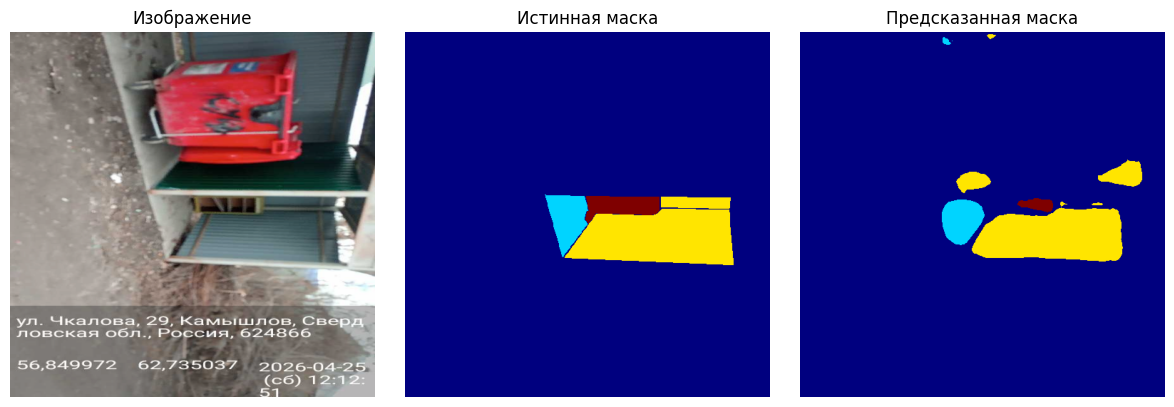

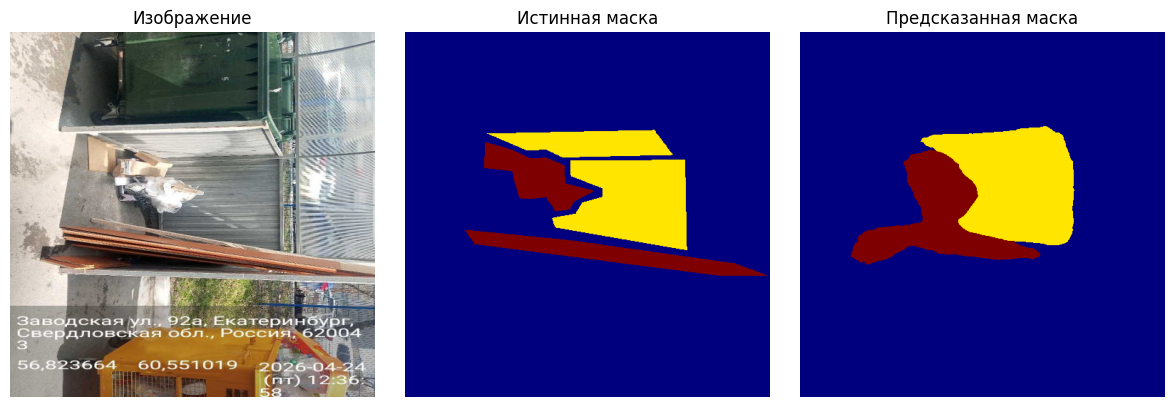

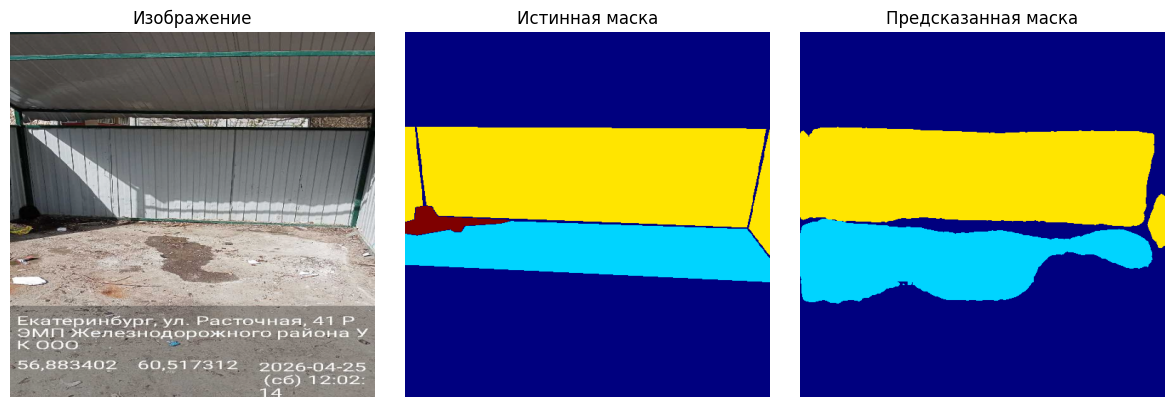

In [152]:
# Загружаем модель
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Функция для предсказания на одном изображении
def predict_one_image(model, image_path, transform=val_transform, device=DEVICE):
    """Возвращает предсказанную маску (numpy)"""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    transformed = transform(image=image)
    input_tensor = transformed['image'].unsqueeze(0).to(device, dtype=torch.float32)
    
    with torch.no_grad():
        logits = model(input_tensor)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return pred_mask

# Визуализируем пару примеров из валидационной выборки
for i in range(min(3, len(val_dataset))):
    img_tensor, true_mask = val_dataset[i]
    pred_mask = predict_one_image(model, val_img_paths[i])
    visualize_sample(img_tensor, true_mask, torch.tensor(pred_mask), num_classes=NUM_CLASSES)

In [153]:
def calculate_fill_ratio(mask, class_ids=[3]):
    """
    Вычисляет долю пикселей заданных классов в маске.
    class_ids: список классов, которые считаются мусором (например, [3])
    Возвращает float от 0.0 до 1.0
    """
    total_pixels = mask.size
    garbage_pixels = np.sum(np.isin(mask, class_ids))
    return garbage_pixels / total_pixels

# Пример: классификация «пусто/заполнено»
def classify_kgo_status(pred_mask, threshold=0.5, garbage_class=3):
    ratio = calculate_fill_ratio(pred_mask, [garbage_class])
    if ratio >= threshold:
        return "kgo_full", ratio
    else:
        return "kgo_empty", ratio

# Тест на нескольких изображениях
for i in range(min(5, len(val_dataset))):
    pred_mask = predict_one_image(model, val_img_paths[i])
    status, ratio = classify_kgo_status(pred_mask, threshold=0.5)
    print(f"Изображение {val_img_paths[i]}: заполненность = {ratio:.2%} → {status}")

Изображение dataset/images\2026-04-27_000433.jpg: заполненность = 0.25% → kgo_empty
Изображение dataset/images\2026-04-26_000126.jpg: заполненность = 6.25% → kgo_empty
Изображение dataset/images\2026-04-27_000393.jpg: заполненность = 0.00% → kgo_empty
Изображение dataset/images\2026-04-26_000355.jpg: заполненность = 0.00% → kgo_empty
Изображение dataset/images\2026-04-27_000461.jpg: заполненность = 0.61% → kgo_empty
